# Neural Network Architecture Experiments

This notebook compares multiple neural network architectures for recruitment status classification and evaluates their validation performance.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [23]:
np.random.seed(42)
tf.random.set_seed(42)

In [24]:
data_path = Path("../data/Datasets.xlsx")

df = pd.read_excel(
    data_path,
    sheet_name="Recruitment"
)

X = df.drop(columns=["Candidate_ID", "Status"])
y = df["Status"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [25]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [26]:
numerical_features = [
    "Experience",
    "Tech_Score",
    "Interview"
]

categorical_features = [
    "Position"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [27]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

input_size = X_train_processed.shape[1]

print("Input features:", input_size)

Input features: 6


In [28]:
small_model = Sequential([
    tf.keras.Input(shape=(input_size,)),
    Dense(16, activation="relu"),
    Dense(3, activation="softmax")
])

small_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [29]:
small_history = small_model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=100,
    batch_size=16,
    verbose=0
)

In [30]:
print(
    f"Small Model Training Accuracy: "
    f"{small_history.history['accuracy'][-1] * 100:.2f}%"
)

print(
    f"Small Model Validation Accuracy: "
    f"{small_history.history['val_accuracy'][-1] * 100:.2f}%"
)

Small Model Training Accuracy: 74.29%
Small Model Validation Accuracy: 60.00%


In [31]:
medium_model = Sequential([
    tf.keras.Input(shape=(input_size,)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(3, activation="softmax")
])

medium_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [32]:
medium_history = medium_model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=100,
    batch_size=16,
    verbose=0
)

In [33]:
medium_history = medium_model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=100,
    batch_size=16,
    verbose=0
)

In [34]:
print(
    f"Medium Model Training Accuracy: "
    f"{medium_history.history['accuracy'][-1] * 100:.2f}%"
)

print(
    f"Medium Model Validation Accuracy: "
    f"{medium_history.history['val_accuracy'][-1] * 100:.2f}%"
)

Medium Model Training Accuracy: 90.71%
Medium Model Validation Accuracy: 70.00%


In [35]:
large_model = Sequential([
    tf.keras.Input(shape=(input_size,)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(3, activation="softmax")
])

large_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [36]:
large_history = large_model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=100,
    batch_size=16,
    verbose=0
)

In [37]:
print(
    f"Large Model Training Accuracy: "
    f"{large_history.history['accuracy'][-1] * 100:.2f}%"
)

print(
    f"Large Model Validation Accuracy: "
    f"{large_history.history['val_accuracy'][-1] * 100:.2f}%"
)

Large Model Training Accuracy: 94.29%
Large Model Validation Accuracy: 60.00%


In [38]:
results = pd.DataFrame({
    "Model": [
        "Small: 16",
        "Medium: 32-16",
        "Large: 64-32-16"
    ],
    "Training Accuracy": [
        small_history.history["accuracy"][-1],
        medium_history.history["accuracy"][-1],
        large_history.history["accuracy"][-1]
    ],
    "Validation Accuracy": [
        small_history.history["val_accuracy"][-1],
        medium_history.history["val_accuracy"][-1],
        large_history.history["val_accuracy"][-1]
    ],
    "Training Loss": [
        small_history.history["loss"][-1],
        medium_history.history["loss"][-1],
        large_history.history["loss"][-1]
    ],
    "Validation Loss": [
        small_history.history["val_loss"][-1],
        medium_history.history["val_loss"][-1],
        large_history.history["val_loss"][-1]
    ]
})

results

,Model,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss
0,Small: 16,0.742857,0.6,0.506096,0.552101
1,Medium: 32-16,0.907143,0.7,0.233955,0.765658
2,Large: 64-32-16,0.942857,0.6,0.165641,0.770480


In [39]:
display_results = results.copy()

display_results["Training Accuracy"] *= 100
display_results["Validation Accuracy"] *= 100

display_results.round(2)

,Model,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss
0,Small: 16,74.29,60.0,0.51,0.55
1,Medium: 32-16,90.71,70.0,0.23,0.77
2,Large: 64-32-16,94.29,60.0,0.17,0.77


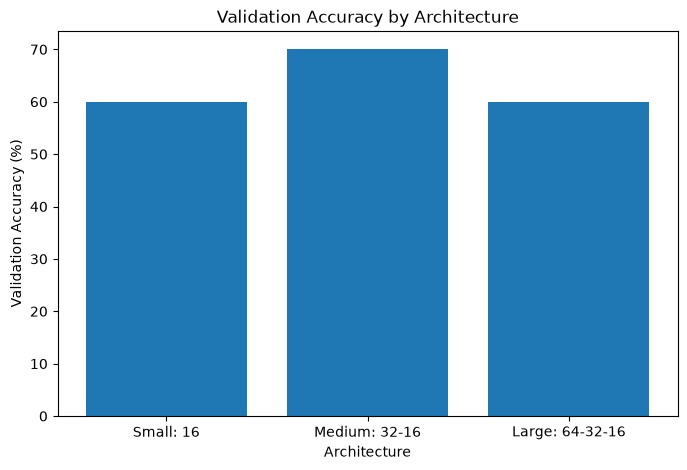

In [40]:
plt.figure(figsize=(8, 5))

plt.bar(
    display_results["Model"],
    display_results["Validation Accuracy"]
)

plt.title("Validation Accuracy by Architecture")
plt.xlabel("Architecture")
plt.ylabel("Validation Accuracy (%)")
plt.show()

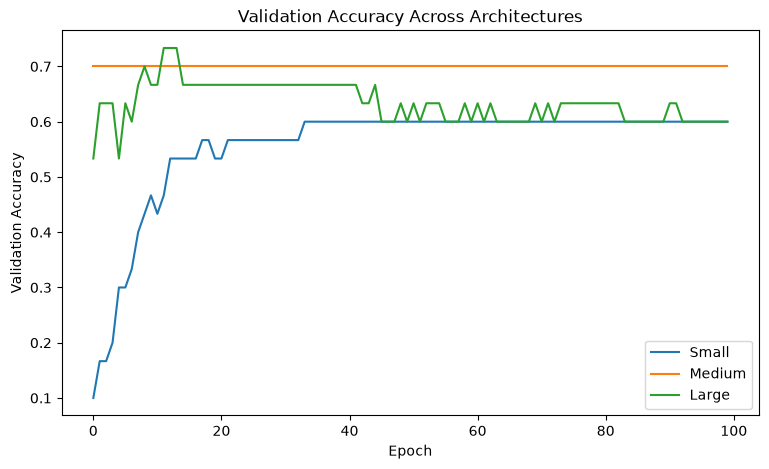

In [41]:
plt.figure(figsize=(9, 5))

plt.plot(
    small_history.history["val_accuracy"],
    label="Small"
)

plt.plot(
    medium_history.history["val_accuracy"],
    label="Medium"
)

plt.plot(
    large_history.history["val_accuracy"],
    label="Large"
)

plt.title("Validation Accuracy Across Architectures")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

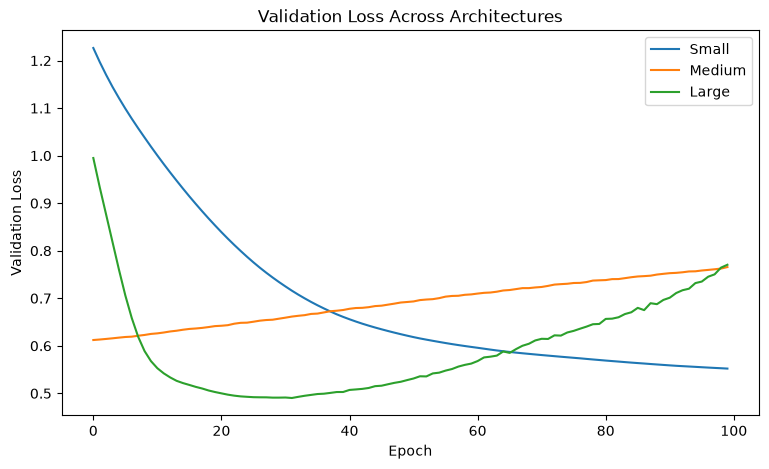

In [42]:
plt.figure(figsize=(9, 5))

plt.plot(
    small_history.history["val_loss"],
    label="Small"
)

plt.plot(
    medium_history.history["val_loss"],
    label="Medium"
)

plt.plot(
    large_history.history["val_loss"],
    label="Large"
)

plt.title("Validation Loss Across Architectures")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

## Architecture Comparison

Three neural network architectures were evaluated:

1. Small model: 16 hidden neurons
2. Medium model: 32 and 16 hidden neurons
3. Large model: 64, 32, and 16 hidden neurons

The models were compared using training accuracy, validation accuracy, training loss, and validation loss.

Greater differences between training and validation performance indicate potential overfitting.